# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
p1 = 8 / 10
p2 = 2 / 10

entropy = -p1 * np.log(p1) - p2 * np.log(p2)

round(entropy, 2)

np.float64(0.5)

**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
p1 = 8 / 10
p2 = 2 / 10

H_parent = p1 * (1 - p1) + p2 * (1 - p2)

H_left = 0
H_right = 0

Q = H_parent - 8 / 10 * H_left - 2 / 10 * H_right

round(Q, 2)

0.32

**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
y = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]

prediction = np.mean(y)

prediction

np.float64(40.6)

## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    
    feature_vector = np.asarray(feature_vector)
    target_vector = np.asarray(target_vector)

    order = np.argsort(feature_vector)
    x = feature_vector[order]
    y = target_vector[order]

    if len(np.unique(x)) == 1:
        return np.array([]), np.array([]), None, None

    if feature_type == "real":
        mask = x[:-1] != x[1:]
        thresholds = (x[:-1][mask] + x[1:][mask]) / 2

        left_count = np.arange(1, len(y))[mask]
        right_count = len(y) - left_count

        if task == "regression":
            left_sum = np.cumsum(y)[:-1][mask]
            right_sum = np.sum(y) - left_sum

            left_sum2 = np.cumsum(y ** 2)[:-1][mask]
            right_sum2 = np.sum(y ** 2) - left_sum2

            left_h = left_sum2 / left_count - (left_sum / left_count) ** 2
            right_h = right_sum2 / right_count - (right_sum / right_count) ** 2

            parent_h = np.var(y)

        else:
            classes = np.unique(y)
            y_one_hot = (y[:, None] == classes[None, :]).astype(int)

            left_counts = np.cumsum(y_one_hot, axis=0)[:-1][mask]
            right_counts = np.sum(y_one_hot, axis=0) - left_counts

            left_p = left_counts / left_count[:, None]
            right_p = right_counts / right_count[:, None]

            left_h = np.sum(left_p * (1 - left_p), axis=1)
            right_h = np.sum(right_p * (1 - right_p), axis=1)

            parent_p = np.mean(y_one_hot, axis=0)
            parent_h = np.sum(parent_p * (1 - parent_p))

        ginis = parent_h - left_count / len(y) * left_h - right_count / len(y) * right_h

    else:
        values = np.unique(x)

        thresholds = values

        if task == "regression":
            total_h = np.var(y)

            left_count = np.array([np.sum(x == value) for value in values])
            right_count = len(y) - left_count

            good = (left_count > 0) & (right_count > 0)

            thresholds = thresholds[good]
            left_count = left_count[good]
            right_count = right_count[good]

            left_h = np.array([np.var(y[x == value]) for value in thresholds])
            right_h = np.array([np.var(y[x != value]) for value in thresholds])

            ginis = total_h - left_count / len(y) * left_h - right_count / len(y) * right_h

        else:
            classes = np.unique(y)
            total_p = np.array([np.mean(y == c) for c in classes])
            total_h = np.sum(total_p * (1 - total_p))

            left_count = np.array([np.sum(x == value) for value in values])
            right_count = len(y) - left_count

            good = (left_count > 0) & (right_count > 0)

            thresholds = thresholds[good]
            left_count = left_count[good]
            right_count = right_count[good]

            left_h = []
            right_h = []

            for value in thresholds:
                left_y = y[x == value]
                right_y = y[x != value]

                left_p = np.array([np.mean(left_y == c) for c in classes])
                right_p = np.array([np.mean(right_y == c) for c in classes])

                left_h.append(np.sum(left_p * (1 - left_p)))
                right_h.append(np.sum(right_p * (1 - right_p)))

            left_h = np.array(left_h)
            right_h = np.array(right_h)

            ginis = total_h - left_count / len(y) * left_h - right_count / len(y) * right_h

    if len(ginis) == 0:
        return np.array([]), np.array([]), None, None

    best_id = np.argmax(ginis)

    threshold_best = thresholds[best_id]
    gini_best = ginis[best_id]

    return thresholds, ginis, threshold_best, gini_best

Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

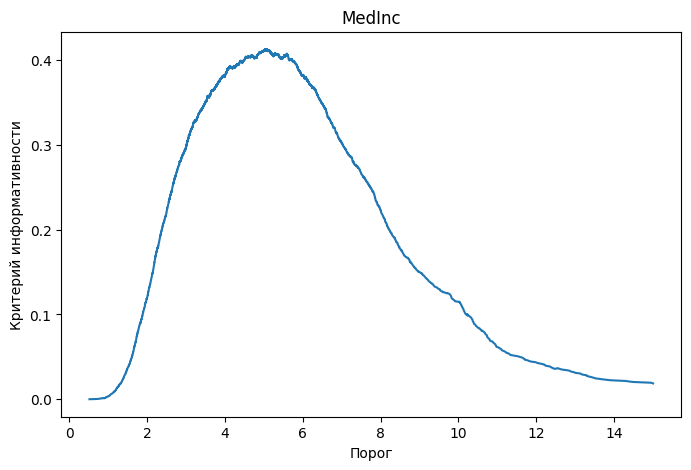

Лучший порог: 5.03515
Лучшее значение критерия: 0.4127513862016846


In [10]:
thresholds, ginis, threshold_best, gini_best = find_best_split(
    X["MedInc"],
    y,
    task="regression",
    feature_type="real"
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, ginis)
plt.xlabel("Порог")
plt.ylabel("Критерий информативности")
plt.title("MedInc")
plt.show()

print("Лучший порог:", threshold_best)
print("Лучшее значение критерия:", gini_best)

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [11]:
best_feature = None
best_threshold = None
best_score = None

for column in X.columns:
    thresholds, ginis, threshold, score = find_best_split(
        X[column],
        y,
        task="regression",
        feature_type="real"
    )

    if score is not None and (best_score is None or score > best_score):
        best_feature = column
        best_threshold = threshold
        best_score = score

print(f"Лучший предикат: {best_feature} <= {best_threshold}")
print(f"Лучшее значение критерия: {best_score}")

Лучший предикат: MedInc <= 5.03515
Лучшее значение критерия: 0.4127513862016846


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [12]:
class DecisionTree:
    
    def __init__(
        self, 
        feature_types: Union[List[str], np.ndarray], 
        max_depth: int = None, 
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}
        
        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types
        
        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        
        # Переменная, если вы решите делать бонус
        self._feature_importances = {}
        

    def _fit_node(self, sub_X: np.ndarray, sub_y: np.ndarray, node: dict, depth=0) -> None:
        
        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return
        
        if self._max_depth is not None and depth >= self._max_depth:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        if self._min_samples_split is not None and len(sub_y) < self._min_samples_split:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini is None or threshold is None:
                continue

            
            current_split = feature_vector <= threshold if feature_type == "real" else feature_vector == threshold

            if self._min_samples_leaf is not None:
                if np.sum(current_split) < self._min_samples_leaf or np.sum(~current_split) < self._min_samples_leaf:
                    continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                threshold_best = threshold
                gini_best = gini
                split = current_split

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError("Unknown feature type")
            
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"], depth + 1)

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]

        if self._feature_types[feature] == "real":
            if x[feature] <= node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

        elif self._feature_types[feature] == "categorical":
            if x[feature] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

        else:
            raise ValueError("Unknown feature type")    

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree, depth=0)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
            
        return np.array(predicted)

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

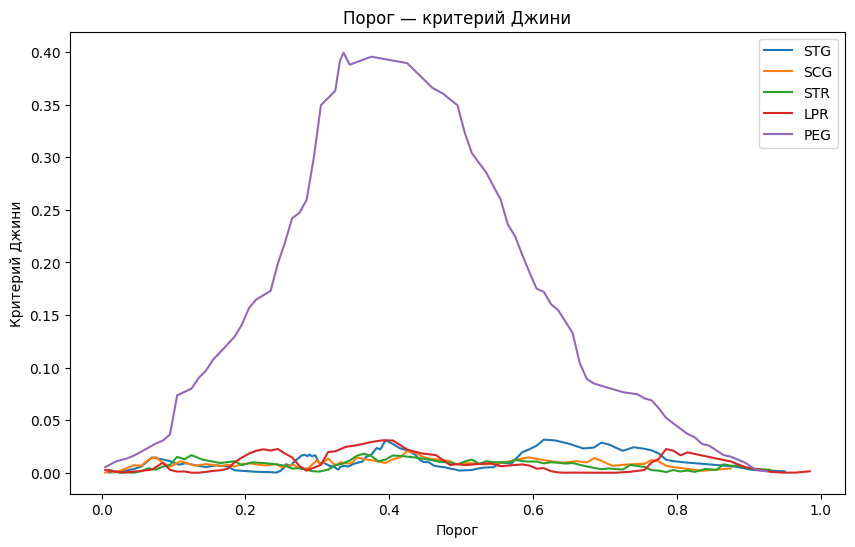

Лучший признак: PEG
Лучшее значение критерия: 0.39939200196213387


In [13]:
students = pd.read_csv("students.csv")
students = students.loc[:, ~students.columns.str.contains("^Unnamed")]

X_students = students.iloc[:, :-1]
y_students = students.iloc[:, -1]

best_scores = {}

plt.figure(figsize=(10, 6))

for column in X_students.columns:
    thresholds, ginis, threshold_best, gini_best = find_best_split(
        X_students[column],
        y_students,
        task="classification",
        feature_type="real"
    )
    best_scores[column] = gini_best
    plt.plot(thresholds, ginis, label=column)

plt.xlabel("Порог")
plt.ylabel("Критерий Джини")
plt.title("Порог — критерий Джини")
plt.legend()
plt.show()

best_feature = max(best_scores, key=best_scores.get)
print("Лучший признак:", best_feature)
print("Лучшее значение критерия:", best_scores[best_feature])

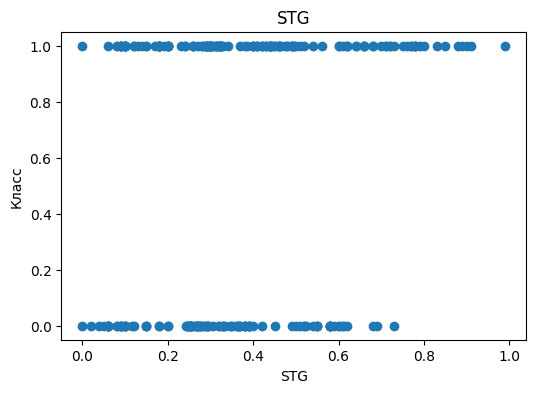

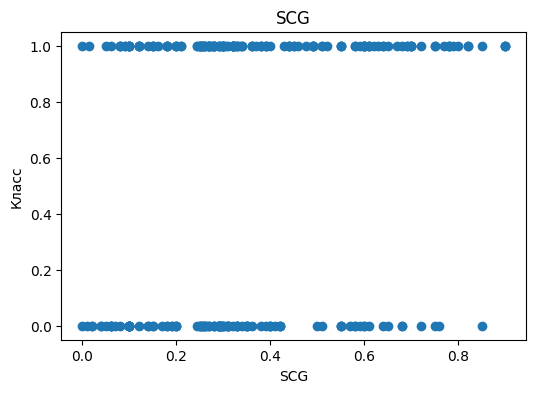

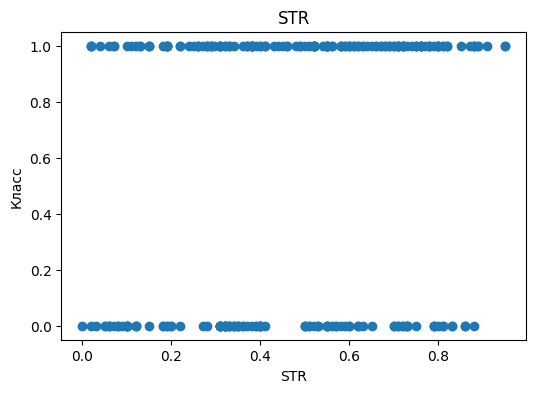

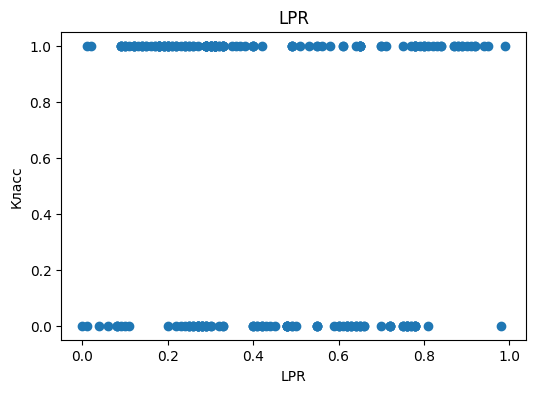

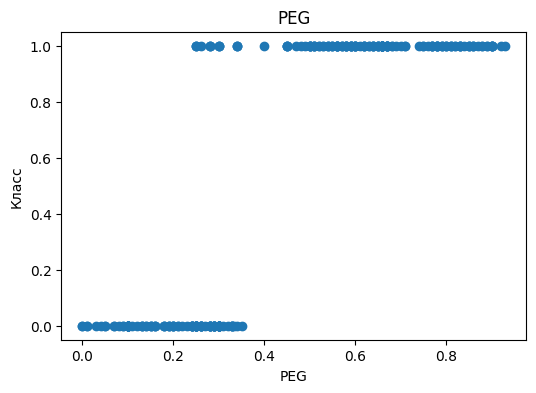

In [14]:
for column in X_students.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_students[column], y_students)
    plt.xlabel(column)
    plt.ylabel("Класс")
    plt.title(column)
    plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

По кривым критерия Джини лучше всего делить выборку по признаку PEG. Именно для него значение критерия Джини достигает максимума = 0.399. Это означает, что при разбиении выборки по признаку PEG классы разделяются лучше всего: после выбора удачного порога в одном поддереве оказывается в основном один класс, а в другом другой. Этот результат хорошо согласуется с диаграммами рассеяния. На графике для PEG видно наиболее заметное разделение классов: при маленьких значениях PEG чаще встречается класс 0, а при больших значениях класс 1. У остальных признаков (STG, SCG, STR, LPR) точки двух классов сильнее перемешаны, поэтому они хуже подходят для первого разбиения дерева. Для хорошего признака кривая критерия Джини имеет выраженный максимум: это значит, что есть порог, который заметно улучшает разделение классов. Для слабых признаков кривая ниже и без ярко выраженного пика, так как почти любой порог делит классы плохо. Поэтому первое деление дерева логичнее всего делать по признаку PEG.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [15]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = pd.read_csv("agaricus-lepiota.data", header=None)

for column in data.columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])

X = data.iloc[:, 1:]
y = data.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y.values.ravel(), 
    test_size=0.5, 
    random_state=42
)

tree = DecisionTree(
    feature_types=["categorical"] * X_train.shape[1],
    task="classification"
)

tree.fit(X_train.values, y_train)

train_pred = tree.predict(X_train.values)
test_pred = tree.predict(X_test.values)

y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

Train accuracy: 1.0
Test accuracy: 1.0


В целом, для датасета mushrooms такой результат норм (accuracy = 1.0). Там признаки очень хорошо отделяют ядовитые грибы от съедобных.

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [16]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [17]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

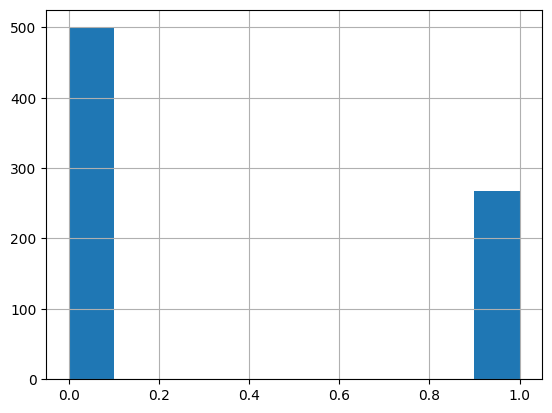

In [18]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [19]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.3,
    random_state=42,
    stratify=y_train_full
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(375, 8)
(162, 8)
(231, 8)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [20]:
from sklearn.metrics import f1_score

In [21]:
depths = [2, 3, 4, 5, 6, 7, 8, 10]
leafs = [1, 2, 3, 5, 10, 15, 20]

best_f1 = -1
best_params_tree = None

for depth in depths:
    for leaf in leafs:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        pred_val = model.predict(X_val)
        f1 = f1_score(y_val, pred_val)
        
        if f1 > best_f1:
            best_f1 = f1
            best_params_tree = (depth, leaf)

print("Лучшие параметры:", best_params_tree)
print("Лучший F1 на validation:", best_f1)

Лучшие параметры: (5, 20)
Лучший F1 на validation: 0.625


In [22]:
best_depth, best_leaf = best_params_tree

tree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    random_state=42
)

tree_model.fit(X_train_full, y_train_full)

pred_test = tree_model.predict(X_test)
proba_test = tree_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test))
print("Recall:", recall_score(y_test, pred_test))
print("AUC ROC:", roc_auc_score(y_test, proba_test))

Accuracy: 0.7272727272727273
Precision: 0.6451612903225806
Recall: 0.49382716049382713
AUC ROC: 0.7951028806584362


У решающего дерева accuracy = 0.727, precision = 0.645, recall = 0.494 и AUC ROC = 0.795. Модель показывает нормальное качество классификации, accuracy выше 0.7, значит дерево правильно классифицирует большую часть объектов. Precision 0.645, значит модель предсказывает диабет, и в большинстве случаев это действительно так. Recall получился ниже 0,5, значит дерево находит только около половины пациентов с диабетом, пропускает часть положительных случаев. AUC ROC = 0,795, значит модель достаточно хорошо разделяет классы, но качество всё ещё ограничено из-за простоты метода одного дерева.

**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [23]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train_full, y_train_full)

pred_test = bagging_model.predict(X_test)
proba_test = bagging_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test))
print("Recall:", recall_score(y_test, pred_test))
print("AUC ROC:", roc_auc_score(y_test, proba_test))

Accuracy: 0.7532467532467533
Precision: 0.6875
Recall: 0.5432098765432098
AUC ROC: 0.8269135802469136


Бэггинг показал качество лучше, чем одно решающее дерево, выросли accuracy, recall и AUC ROC. Бэггинг обучает несколько деревьев на разных bootstrap выборках и усредняет их ответы, из-за чего модель становится устойчивее и меньше переобучается. Precision тоже достаточно хороший (если модель предсказывает диабет, она часто оказывается права). При этом recall всё ещё не очень высокий, то есть часть пациентов с диабетом модель всё равно пропускает.

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [24]:
from sklearn.model_selection import cross_val_score

depths = [2, 3, 4, 5, 6, 7, 8, 10]
splits = [2, 5, 10, 15, 20, 30]

best_f1 = -1
best_params_rf = None

for depth in depths:
    for split in splits:
        rf = RandomForestClassifier(
            n_estimators=50,
            max_depth=depth,
            min_samples_split=split,
            random_state=42
        )
        
        scores = cross_val_score(
            rf,
            X_train_full,
            y_train_full,
            cv=5,
            scoring='f1'
        )
        
        mean_score = scores.mean()
        
        if mean_score > best_f1:
            best_f1 = mean_score
            best_params_rf = (depth, split)

print("Лучшие параметры:", best_params_rf)
print("Лучший средний F1:", best_f1)

Лучшие параметры: (10, 5)
Лучший средний F1: 0.6320517837641064


In [25]:
best_depth, best_split = best_params_rf

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_depth,
    min_samples_split=best_split,
    random_state=42
)

rf_model.fit(X_train_full, y_train_full)

pred_test = rf_model.predict(X_test)
proba_test = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred_test))
print("Precision:", precision_score(y_test, pred_test))
print("Recall:", recall_score(y_test, pred_test))
print("AUC ROC:", roc_auc_score(y_test, proba_test))

Accuracy: 0.7575757575757576
Precision: 0.6865671641791045
Recall: 0.5679012345679012
AUC ROC: 0.8269958847736626


Среди трёх моделей лучше всего показал себя случайный лес, так как у него accuracy = 0.758, precision = 0.687, recall = 0.568 и AUC ROC = 0.827. Самый важный здесь AUC ROC, так как он показывает способность модели разделять классы независимо от выбранного порога. Значение 0.827 говорит о хорошем качестве классификации. Однако его преимущество над бэггингом очень небольшое. AUC ROC почти одинаковый, а precision у бэггинга даже немного выше. Поэтому нельзя сказать, что случайный лес резко лучше бэггинга, но по совокупности метрик он всё же выглядит лучшим вариантом. Ещё случайный лес показал результат лучше, чем одно решающее дерево, так как использовал ансамбль из множества деревьев, уменьшил переобучение. Он лучше обычного бэггинга, так как дополнительно случайно выбирает признаки при построении деревьев, и деревья становятся менее похожими друг на друга, значит и модель лучше обобщает данные.

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

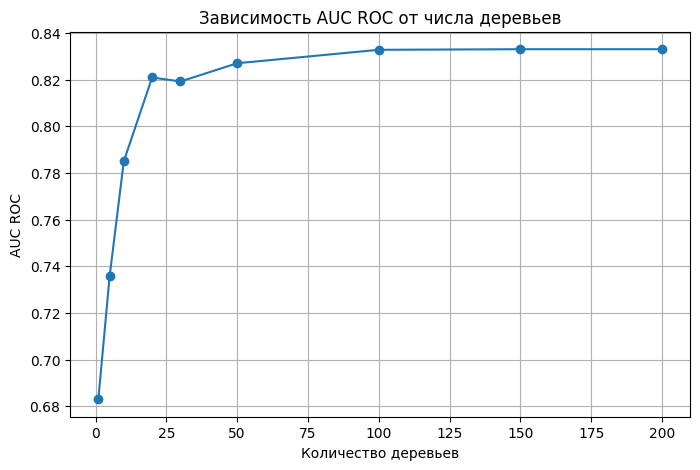

In [26]:
n_estimators_list = [1, 5, 10, 20, 30, 50, 100, 150, 200]
auc_scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_depth,
        min_samples_split=best_split,
        random_state=42
    )
    
    rf.fit(X_train_full, y_train_full)
    proba_test = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba_test)
    
    auc_scores.append(auc)

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, auc_scores, marker='o')
plt.xlabel('Количество деревьев')
plt.ylabel('AUC ROC')
plt.title('Зависимость AUC ROC от числа деревьев')
plt.grid()
plt.show()

На графике видно, что при увеличении числа деревьев AUC ROC сначала быстро растёт (модель становится устойчивее и лучше разделяет классы). Самый сильный рост примерно до 20–50 деревьев. После этого качество почти перестаёт увеличиваться, кривая становится стабильной, выходит на плато около 0.83-0.84, значит, добавлять слишком много деревьев особого смысла нет, здесь уже качество почти не улучшается, зато модель обучается дольше. В данном случае 50 деревьев уже дают хорошее качество.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

In [27]:
importances = rf_model.feature_importances_

feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importances

,feature,importance
1,Glucose,0.281868
5,BMI,0.162722
7,Age,0.127024
6,DiabetesPedigreeFunction,0.116599
0,Pregnancies,0.096706
2,BloodPressure,0.081046
4,Insulin,0.070756
3,SkinThickness,0.063280


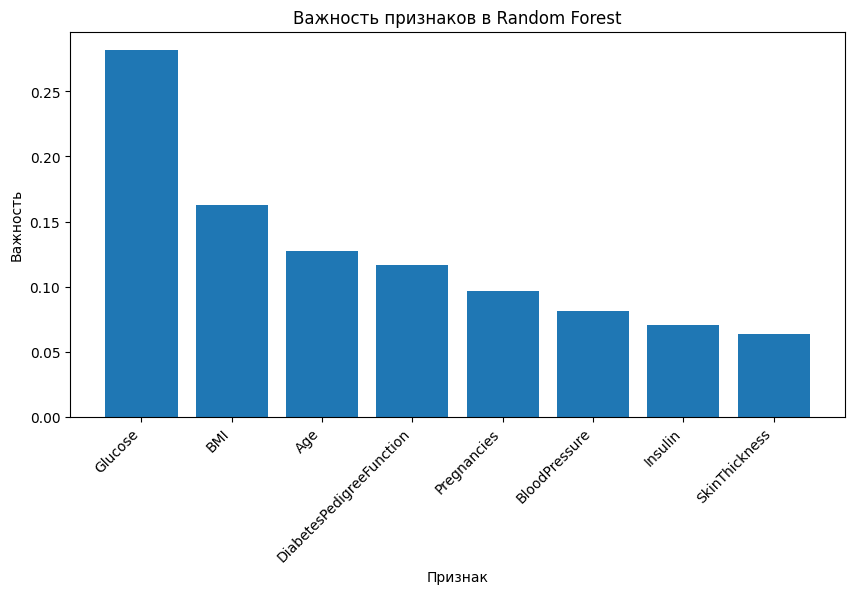

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(feature_importances['feature'], feature_importances['importance'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.title('Важность признаков в Random Forest')
plt.show()

In [29]:
print("Самый важный признак:", feature_importances.iloc[0]['feature'])

Самый важный признак: Glucose


Самым важным признаком для определения диабета оказался Glucose. Всё логично, так как повышенный уровень глюкозы напрямую связан с диабетом и является одним из главных диагностических показателей заболевания.